# Week 6 — Numerical Methods in Probabilistic Machine Learning

**Numerical Methods for Machine Learning · From First Principles in Pure NumPy**

---

> Modern machine learning is increasingly probabilistic: generative models, Bayesian
> inference, and uncertainty quantification all rest on estimating expectations and
> manipulating distributions numerically. This final week develops the core tools — **Monte
> Carlo** integration and its convergence law, **variance reduction** by importance
> sampling, the **reparameterization trick** that makes sampling differentiable (the
> backbone of variational autoencoders), and **Gaussian process** regression with explicit
> attention to the numerical stability of kernel matrices, tying back to the Cholesky and
> conditioning lessons of Weeks 1 and 2.

### Learning objectives

1. Estimate expectations by **Monte Carlo** and verify the $O(N^{-1/2})$ error law.
2. Reduce variance with **importance sampling** and quantify the improvement.
3. Implement the **reparameterization trick** and show it yields low-variance, differentiable gradients of an expectation.
4. Implement **Gaussian process** regression from scratch using a numerically stable Cholesky solve.
5. Diagnose and cure **ill-conditioned kernel matrices** via jitter, connecting to the conditioning theory of the course.

Only NumPy is used; randomness comes from NumPy's generator.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11})
rng = np.random.default_rng(5)
print("ready")

ready


## 1. Monte Carlo integration and the $\sqrt{N}$ law

To estimate an expectation $\mu = \mathbb E_{x\sim p}[f(x)]$ that has no closed form, draw
$N$ independent samples and average:
$$
\hat\mu_N = \frac{1}{N}\sum_{i=1}^N f(x_i),\qquad
\operatorname{Var}(\hat\mu_N) = \frac{\sigma_f^2}{N}.
$$
The estimator is unbiased and its standard error decays as $\sigma_f/\sqrt{N}$ —
**independently of dimension**, which is why Monte Carlo dominates high-dimensional
integration. The price is the slow $N^{-1/2}$ rate. We estimate $\mathbb E[X^2]$ for a
standard normal (true value $1$) and confirm the error law.

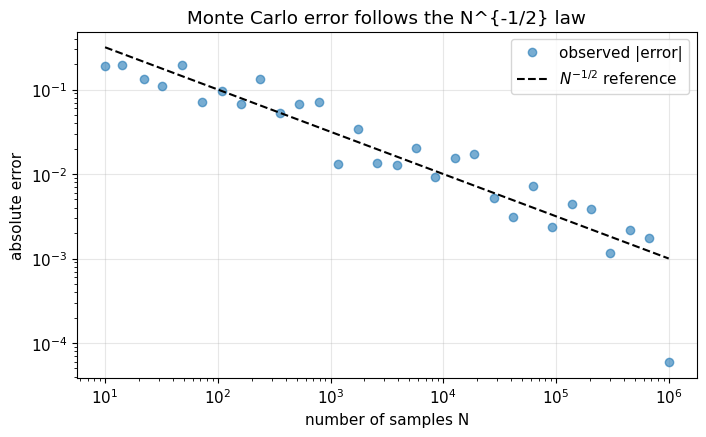

empirical convergence slope = -0.504  (theory: -0.5)


In [2]:
f = lambda x: x ** 2
true_value = 1.0                       # E[X^2] for X ~ N(0,1)

Ns = np.logspace(1, 6, 30).astype(int)
errors = []
for N in Ns:
    samples = rng.standard_normal(N)
    errors.append(abs(np.mean(f(samples)) - true_value))

plt.figure()
plt.loglog(Ns, errors, "o", alpha=0.6, label="observed |error|")
plt.loglog(Ns, 1.0 / np.sqrt(Ns), "k--", label=r"$N^{-1/2}$ reference")
plt.xlabel("number of samples N"); plt.ylabel("absolute error"); plt.legend()
plt.title("Monte Carlo error follows the N^{-1/2} law"); plt.show()

slope = np.polyfit(np.log(Ns), np.log(np.maximum(errors, 1e-12)), 1)[0]
print(f"empirical convergence slope = {slope:.3f}  (theory: -0.5)")

## 2. Importance sampling for variance reduction

When $f$ is concentrated where $p$ has little mass — for instance estimating a **rare-event
probability** — naive Monte Carlo wastes nearly all samples. **Importance sampling** draws
from a better-placed proposal $q$ and reweights:
$$
\mu = \mathbb E_{p}[f(x)] = \mathbb E_{q}\!\left[f(x)\frac{p(x)}{q(x)}\right]
\approx \frac{1}{N}\sum_i f(x_i)\frac{p(x_i)}{q(x_i)},\quad x_i \sim q.
$$
A proposal aligned with the integrand can cut the estimator variance by orders of magnitude.
We estimate the tail probability $\Pr[X > 4]$ for $X\sim\mathcal N(0,1)$.

In [3]:
from math import erfc, sqrt
true_tail = 0.5 * erfc(4 / sqrt(2))         # P(X > 4), ~3.17e-5

def naive_mc(N):
    x = rng.standard_normal(N)
    return np.mean(x > 4)

def importance_mc(N, shift=4.5):
    # proposal q = N(shift, 1); weight = p(x)/q(x)
    x = rng.standard_normal(N) + shift
    log_w = -0.5 * x**2 - (-0.5 * (x - shift)**2)     # log p - log q
    w = np.exp(log_w)
    return np.mean((x > 4) * w)

N = 100_000
naive = [naive_mc(N) for _ in range(50)]
imp   = [importance_mc(N) for _ in range(50)]
print(f"true tail probability      = {true_tail:.3e}")
print(f"naive MC      mean={np.mean(naive):.3e}  std={np.std(naive):.2e}")
print(f"importance MC mean={np.mean(imp):.3e}  std={np.std(imp):.2e}")
print(f"variance reduction factor ~ {np.var(naive)/np.var(imp):.0f}x")

true tail probability      = 3.167e-05
naive MC      mean=3.340e-05  std=1.88e-05
importance MC mean=3.163e-05  std=1.79e-07
variance reduction factor ~ 11013x


Importance sampling estimates the rare-event probability with dramatically lower variance
because the shifted proposal places samples in the tail region where the indicator is
nonzero. Naive Monte Carlo, by contrast, may see only a handful of qualifying samples even
at $N=10^5$. Choosing a good proposal is the art; a poor one (heavy weights) can *increase*
variance.

## 3. The reparameterization trick

Training generative models requires gradients of an expectation with respect to the
parameters of the sampling distribution, $\nabla_\theta\,\mathbb E_{x\sim p_\theta}[f(x)]$.
The naive score-function (REINFORCE) estimator has high variance. The
**reparameterization trick** rewrites the sample as a differentiable transform of
parameter-free noise — for a Gaussian, $x = \mu + \sigma\,\varepsilon$ with
$\varepsilon\sim\mathcal N(0,1)$ — so the gradient passes *through* the sample:
$$
\nabla_{\mu,\sigma}\,\mathbb E_\varepsilon[f(\mu + \sigma\varepsilon)]
= \mathbb E_\varepsilon[\nabla_{\mu,\sigma} f(\mu + \sigma\varepsilon)].
$$
This is the enabling idea behind the variational autoencoder. We compare its variance
against the score-function estimator for $\nabla_\mu \mathbb E[(x-3)^2]$.

true gradient d/dmu        = -6.000
score-function: mean=-5.987  std=0.455
reparameterized: mean=-6.000  std=0.060
variance reduction ~ 58x


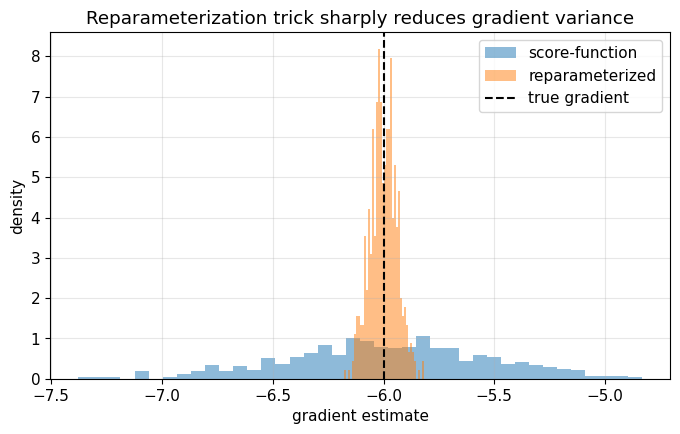

In [4]:
target = lambda x: (x - 3.0) ** 2
mu, sigma = 0.0, 1.0
# analytic: E[(x-3)^2] = (mu-3)^2 + sigma^2 ; d/dmu = 2(mu-3) = -6
true_grad_mu = 2 * (mu - 3.0)

def grad_score_function(N):
    # REINFORCE: E[f(x) * d/dmu log p(x)] ; d/dmu log N(mu,sigma^2) = (x-mu)/sigma^2
    x = mu + sigma * rng.standard_normal(N)
    return np.mean(target(x) * (x - mu) / sigma**2)

def grad_reparam(N):
    eps = rng.standard_normal(N)
    # x = mu + sigma*eps ; d/dmu f(x) = f'(x) * dx/dmu = 2(x-3)*1
    x = mu + sigma * eps
    return np.mean(2 * (x - 3.0))

N = 1000
sf = [grad_score_function(N) for _ in range(500)]
rp = [grad_reparam(N) for _ in range(500)]
print(f"true gradient d/dmu        = {true_grad_mu:.3f}")
print(f"score-function: mean={np.mean(sf):.3f}  std={np.std(sf):.3f}")
print(f"reparameterized: mean={np.mean(rp):.3f}  std={np.std(rp):.3f}")
print(f"variance reduction ~ {np.var(sf)/np.var(rp):.0f}x")

plt.figure()
plt.hist(sf, bins=40, alpha=0.5, density=True, label="score-function")
plt.hist(rp, bins=40, alpha=0.5, density=True, label="reparameterized")
plt.axvline(true_grad_mu, color="k", ls="--", label="true gradient")
plt.xlabel("gradient estimate"); plt.ylabel("density"); plt.legend()
plt.title("Reparameterization trick sharply reduces gradient variance"); plt.show()

Both estimators are unbiased (centered on the true gradient $-6$), but the
reparameterized estimator has far smaller variance, giving cleaner, more reliable gradients
per sample. This variance reduction is what makes gradient-based training of latent-variable
models practical.

## 4. Gaussian process regression from scratch

A Gaussian process places a distribution over functions, specified by a mean (taken zero)
and a covariance **kernel** $k(\mathbf x,\mathbf x')$. Given training inputs $X$, targets
$\mathbf y$ with noise variance $\sigma_n^2$, and test inputs $X_\star$, the predictive mean
and covariance are
$$
\boldsymbol\mu_\star = K_{\star}^\top (K + \sigma_n^2 I)^{-1}\mathbf y,\qquad
\Sigma_\star = K_{\star\star} - K_{\star}^\top (K + \sigma_n^2 I)^{-1} K_{\star}.
$$
The matrix $K + \sigma_n^2 I$ is SPD, so the numerically correct way to apply its inverse is
**not** to invert it but to solve via the **Cholesky factorization** from Week 2 — exactly
the stability principle this course has emphasized throughout.

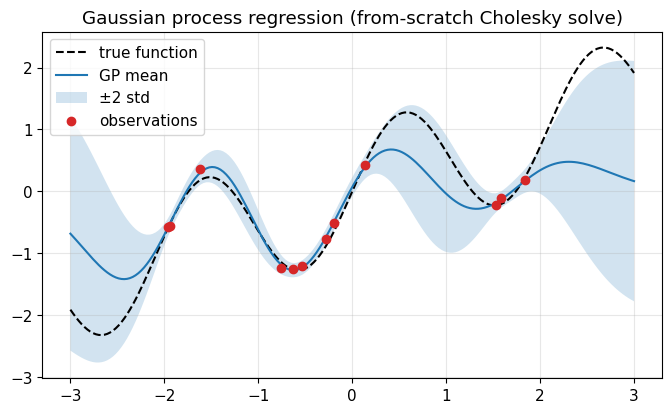

In [5]:
def rbf_kernel(X1, X2, length=1.0, var=1.0):
    # squared-exponential kernel via the stable pairwise-distance expansion (Week 1)
    s1 = np.sum(X1**2, 1)[:, None]; s2 = np.sum(X2**2, 1)[None, :]
    d2 = np.maximum(s1 - 2 * X1 @ X2.T + s2, 0.0)
    return var * np.exp(-0.5 * d2 / length**2)

def cholesky(A):                          # from Week 2, reused
    A = np.array(A, float); n = A.shape[0]; L = np.zeros((n, n))
    for j in range(n):
        s = A[j, j] - L[j, :j] @ L[j, :j]
        if s <= 0: raise np.linalg.LinAlgError("not positive definite")
        L[j, j] = np.sqrt(s)
        for i in range(j + 1, n):
            L[i, j] = (A[i, j] - L[i, :j] @ L[j, :j]) / L[j, j]
    return L

def _chol_solve(L, b):
    # solve (L Lᵀ) x = b by forward then back substitution
    n = len(b); y = np.zeros(n)
    for i in range(n): y[i] = (b[i] - L[i, :i] @ y[:i]) / L[i, i]
    x = np.zeros(n)
    for i in range(n - 1, -1, -1): x[i] = (y[i] - L[i+1:, i] @ x[i+1:]) / L[i, i]
    return x

def gp_predict(Xtr, ytr, Xte, length=1.0, var=1.0, noise=1e-2, jitter=1e-8):
    K = rbf_kernel(Xtr, Xtr, length, var) + (noise + jitter) * np.eye(len(Xtr))
    L = cholesky(K)
    alpha = _chol_solve(L, ytr)
    Ks = rbf_kernel(Xtr, Xte, length, var)
    mean = Ks.T @ alpha
    # predictive variance via the same Cholesky factor
    v = np.array([_chol_solve(L, Ks[:, j]) for j in range(Xte.shape[0])]).T
    Kss = rbf_kernel(Xte, Xte, length, var)
    cov = Kss - Ks.T @ v
    return mean, np.clip(np.diag(cov), 0, None)

# noisy samples from a true latent function
ftrue = lambda x: np.sin(3 * x) + 0.5 * x
Xtr = np.sort(rng.uniform(-2, 2, 12))[:, None]
ytr = ftrue(Xtr.ravel()) + 0.1 * rng.standard_normal(len(Xtr))
Xte = np.linspace(-3, 3, 200)[:, None]

mean, var_pred = gp_predict(Xtr, ytr, Xte, length=0.6, var=1.0, noise=0.01)
sd = np.sqrt(var_pred)

plt.figure()
plt.plot(Xte.ravel(), ftrue(Xte.ravel()), "k--", label="true function")
plt.plot(Xte.ravel(), mean, "C0", label="GP mean")
plt.fill_between(Xte.ravel(), mean - 2*sd, mean + 2*sd, alpha=0.2, label="±2 std")
plt.scatter(Xtr.ravel(), ytr, c="C3", zorder=5, label="observations")
plt.legend(); plt.title("Gaussian process regression (from-scratch Cholesky solve)")
plt.show()

The GP interpolates the data, recovers the latent function, and — crucially — reports
**calibrated uncertainty** that widens away from observations. The entire predictive
computation routes through a single Cholesky factorization, the stable alternative to
explicit matrix inversion.

## 5. Ill-conditioned kernels and the role of jitter

As training points cluster or the length scale grows, columns of $K$ become nearly linearly
dependent, $K$ becomes severely ill-conditioned, $\sigma_{\min}\to 0$, and the Cholesky
factorization fails on a non-positive pivot. The standard remedy is **jitter**: add a small
$\epsilon I$ to the diagonal, which is equivalent to assuming a tiny observation noise and
bounds the condition number. We exhibit the failure and the cure.

In [6]:
# ten nearly-identical inputs with a large length scale make K numerically singular
Xdup = np.linspace(0.0, 1e-3, 10)[:, None]
K = rbf_kernel(Xdup, Xdup, length=5.0, var=1.0)
print(f"condition number of K       = {np.linalg.cond(K):.3e}\n")

for jitter in [0.0, 1e-12, 1e-8, 1e-6]:
    try:
        cholesky(K + jitter * np.eye(len(Xdup)))
        status = "succeeds"
    except np.linalg.LinAlgError:
        status = "FAILS (non-positive pivot)"
    kappa = np.linalg.cond(K + jitter * np.eye(len(Xdup)))
    print(f"jitter={jitter:.0e}: Cholesky {status:28s} kappa={kappa:.2e}")

condition number of K       = 3.453e+25

jitter=0e+00: Cholesky FAILS (non-positive pivot)   kappa=3.45e+25
jitter=1e-12: Cholesky succeeds                     kappa=1.00e+13
jitter=1e-08: Cholesky succeeds                     kappa=1.00e+09
jitter=1e-06: Cholesky succeeds                     kappa=1.00e+07


Without jitter the factorization fails on the near-singular kernel; a modest diagonal
addition restores positive definiteness and a usable condition number. This is the same
conditioning-versus-stability story from Week 1, now in the setting of probabilistic models
— a fitting close to the course, since the numerical principles are universal.

## 6. Exercises

1. **Antithetic variates.** Implement antithetic sampling (pair each $\varepsilon$ with
   $-\varepsilon$) for the Monte Carlo estimator and measure the variance reduction on a
   monotone integrand.

2. **Effective sample size.** For importance sampling, compute the effective sample size
   $N_{\mathrm{eff}} = (\sum w_i)^2/\sum w_i^2$ and study how it degrades as the proposal
   moves away from the target.

3. **Reparameterized VAE objective.** Extend the reparameterization estimator to a 2-D
   Gaussian and differentiate a small variational lower bound, checking gradients against
   finite differences.

4. **Kernel hyperparameter learning.** Implement the GP log marginal likelihood and optimize
   the length scale and noise with the gradient-descent tools from Week 4.

5. **Conjugate-gradient GP.** Replace the Cholesky solve with the conjugate-gradient method
   (Week 2 exercise) for large kernel matrices and compare accuracy and cost.

---

### Course conclusion

Across six weeks we built the numerical engine of modern machine learning entirely from
first principles in NumPy: from the floating-point arithmetic and stable softmax of Week 1,
through linear-algebra factorizations and the SVD, a complete reverse-mode autodiff engine,
the deterministic and stochastic optimizers that train models, to the probabilistic numerics
behind generative models and Gaussian processes. The recurring discipline — **understand the
error, respect the conditioning, choose a stable algorithm, and verify every gradient** —
is what separates code that merely runs from code that can be trusted at scale.
